Movie Rating and Box Office Revenue Analysis

1. Problem Definition
   
This project explores the relationship between movie ratings and box office revenue.  
The target users are film investors, producers, and entertainment media creators.  
The purpose of this analysis is to examine whether higher-rated movies tend to perform better commercially.  
This project may help users better understand movie market trends and support more informed decisions.

2. Data Source
   
The dataset used in this project is `enhanced_box_office_data(2000 - 2024)u.csv`
.  
It contains movie-related information such as title, genre, year, rating, and revenue.  
This dataset was selected because it is directly relevant to the analytical question.

3. Import Libraries

In [16]:
from pathlib import Path
import warnings 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

4. Load Data

In [17]:
data_path = Path("enhanced_box_office_data(2000-2024)u.csv")
df = pd.read_csv(data_path)
df.head()

,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


5. Initial Inspection

In this step, the dataset is inspected to understand its structure, column names, data types, and missing values.

In [18]:
print(df.head())

print(df.columns)

print(df.info())

print(df.describe())

print(df.isnull().sum())

   Rank           Release Group   $Worldwide    $Domestic  Domestic %  \
0     1  Mission: Impossible II  546388108.0  215409889.0        39.4   
1     2               Gladiator  460583960.0  187705427.0        40.8   
2     3               Cast Away  429632142.0  233632142.0        54.4   
3     4         What Women Want  374111707.0  182811707.0        48.9   
4     5                Dinosaur  349822765.0  137748063.0        39.4   

      $Foreign  Foreign %  Year                        Genres    Rating  \
0  330978219.0       60.6  2000   Adventure, Action, Thriller  6.126/10   
1  272878533.0       59.2  2000      Action, Drama, Adventure  8.217/10   
2  196000000.0       45.6  2000              Adventure, Drama  7.663/10   
3  191300000.0       51.1  2000               Comedy, Romance   6.45/10   
4  212074702.0       60.6  2000  Animation, Family, Adventure  6.544/10   

   Vote_Count Original_Language                      Production_Countries  
0      6741.0                en   

6. Data Cleaning

In this step, duplicate records were removed, key columns were selected, missing values were handled, and important variables were converted into numeric format for analysis.

In [19]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.rename(columns={
    "release_group": "title",
    "$worldwide": "worldwide",
    "$domestic": "domestic",
    "domestic_%": "domestic_pct",
    "$foreign": "foreign",
    "foreign_%": "foreign_pct"})
print(df.columns.tolist())
keep_cols = ["title","worldwide", "year", "genres", "rating", "vote_count",
             "original_language", "production_countries"]
df_clean = df[keep_cols].copy()
df_clean = df_clean.drop_duplicates()
print(df_clean.isnull().sum())
df_clean["rating"] = df_clean["rating"].astype(str).str.extract(r'(\d+\.?\d*)')  [0]
df_clean["rating"] = pd.to_numeric(df_clean["rating"], errors="coerce")
df_clean["year"] = pd.to_numeric(df_clean["year"], errors="coerce")
df_clean["worldwide"] = (
    df_clean["worldwide"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df_clean["worldwide"] = pd.to_numeric(df_clean["worldwide"], errors="coerce")
df_clean = df_clean.dropna(subset=["rating", "worldwide", "year", "genres"])
df_clean = df_clean[(df_clean[
"rating"] >= 0) & (df_clean["rating"] <= 10
)]
df_clean = df_clean[df_clean[
"worldwide"] >= 0
]
df_clean = df_clean[(df_clean[
"year"] >= 2000) & (df_clean["year"] <= 2024
)]

df_clean["main_genre"] = df_clean["genres"].astype(str).str.split(",").str  [0].str.strip()
print(df_clean.info())
print(df_clean.head())
print(df_clean.isna().sum())


['rank', 'title', 'worldwide', 'domestic', 'domestic_pct', 'foreign', 'foreign_pct', 'year', 'genres', 'rating', 'vote_count', 'original_language', 'production_countries']
title                     0
worldwide                 0
year                      0
genres                  178
rating                  170
vote_count              170
original_language       170
production_countries    200
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 4822 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 4822 non-null   object 
 1   worldwide             4822 non-null   float64
 2   year                  4822 non-null   int64  
 3   genres                4822 non-null   object 
 4   rating                4822 non-null   float64
 5   vote_count            4822 non-null   float64
 6   original_language     4822 non-null   object 
 7   production_countries  4797

 7. Analysis and Visualisation

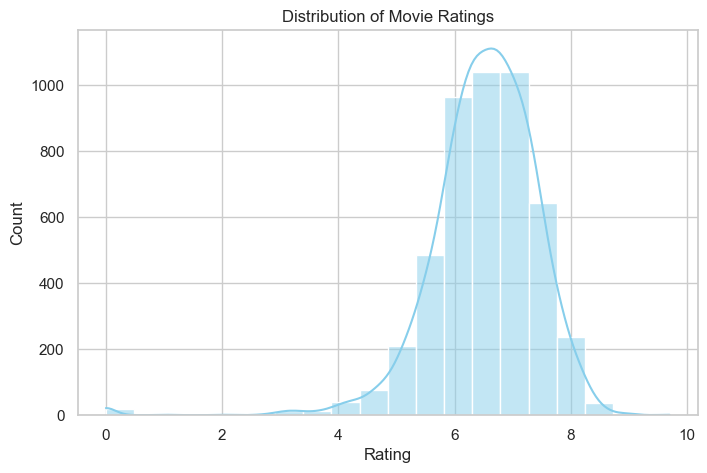

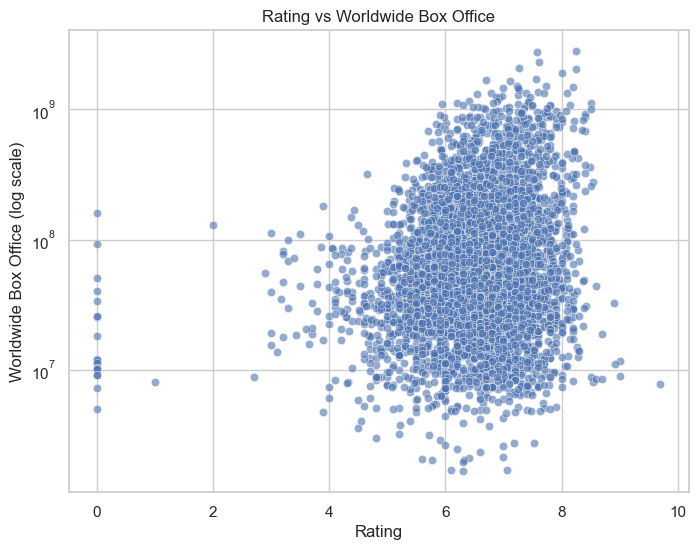

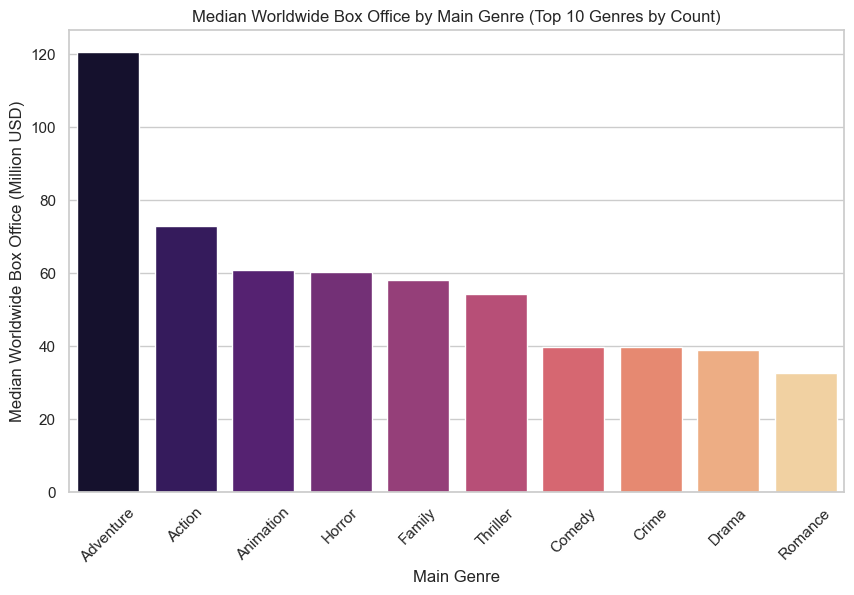

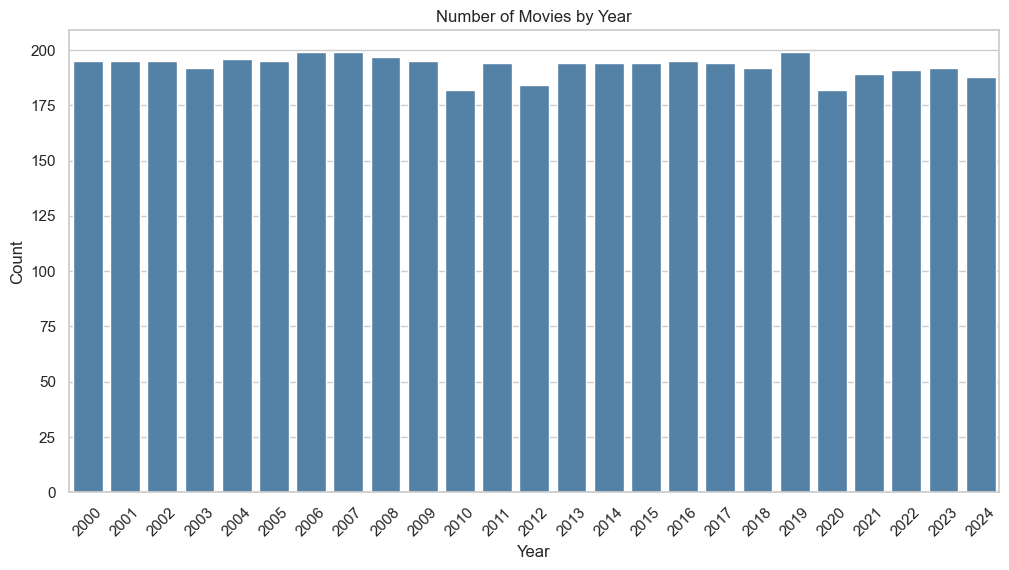

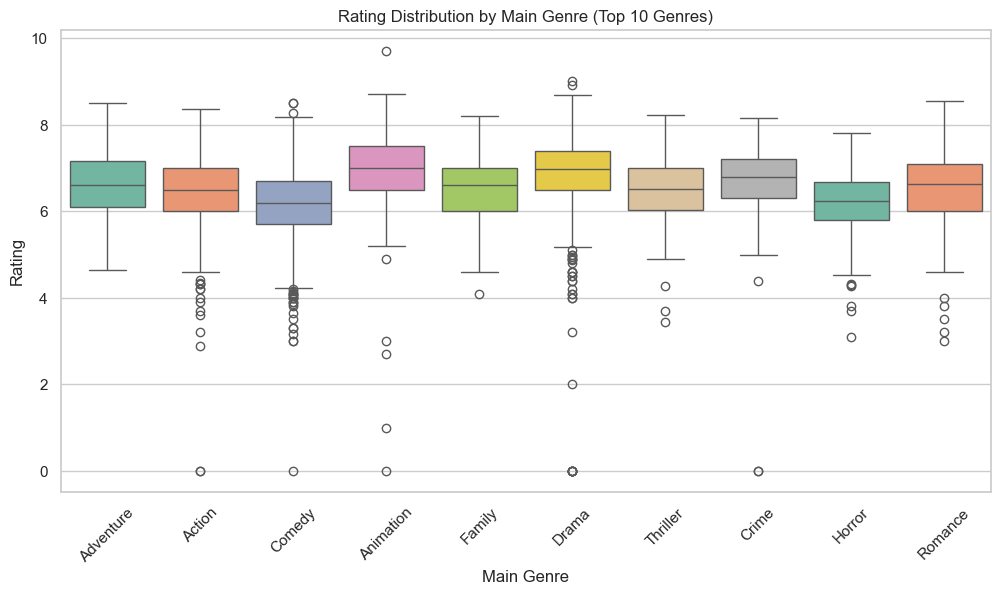

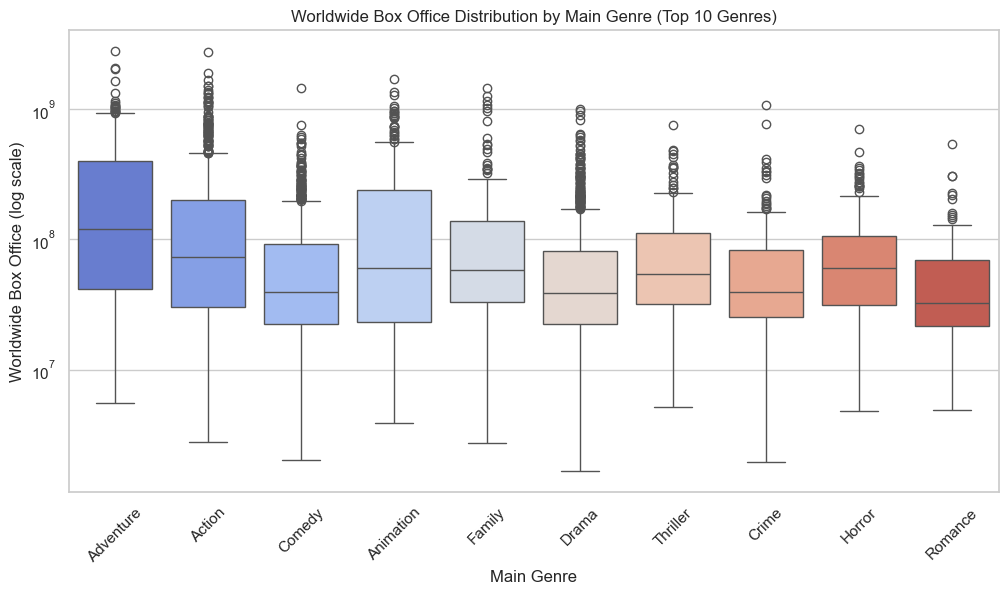

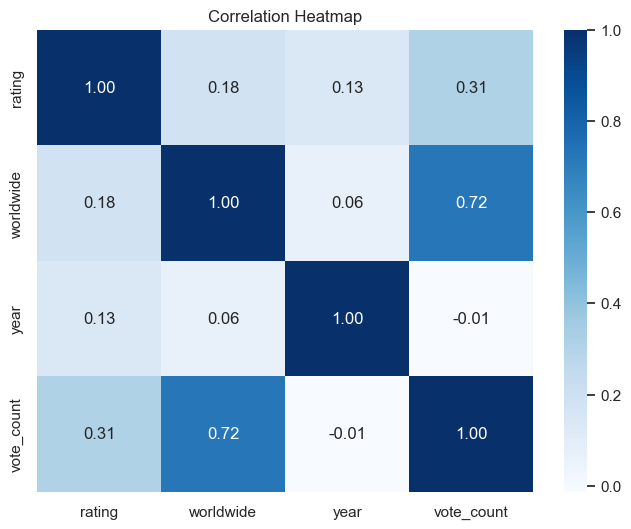

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 为散点图和票房图准备数据
plot_df = df_clean[df_clean["worldwide"] > 0].copy()

# -------------------------
# 1. Rating Distribution
# -------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["rating"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# -------------------------
# 2. Rating vs Worldwide Box Office
# -------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="rating", y="worldwide", alpha=0.6)
plt.yscale("log")
plt.title("Rating vs Worldwide Box Office")
plt.xlabel("Rating")
plt.ylabel("Worldwide Box Office (log scale)")
plt.show()

# -------------------------
# 3. Median Worldwide Box Office by Genre
# -------------------------
genre_summary = (
    df_clean.groupby("main_genre")
    .agg(
        median_worldwide=("worldwide", "median"),
        movie_count=("main_genre", "count")
    )
    .sort_values("movie_count", ascending=False)
)

top_genres = genre_summary.head(10).copy()
top_genres["median_worldwide_million"] = top_genres["median_worldwide"] / 1e6
top_genres = top_genres.sort_values("median_worldwide_million", ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_genres,
    x="main_genre",
    y="median_worldwide_million",
    palette="magma"
)
plt.title("Median Worldwide Box Office by Main Genre (Top 10 Genres by Count)")
plt.xlabel("Main Genre")
plt.ylabel("Median Worldwide Box Office (Million USD)")
plt.xticks(rotation=45)
plt.show()

# -------------------------
# 4. Number of Movies by Year
# -------------------------
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, x="year", color="steelblue")
plt.title("Number of Movies by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# -------------------------
# 5. Rating Distribution by Main Genre
# -------------------------
top_genre_names = df_clean["main_genre"].value_counts().head(10).index
genre_rating_df = df_clean[df_clean["main_genre"].isin(top_genre_names)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=genre_rating_df, x="main_genre", y="rating", palette="Set2")
plt.title("Rating Distribution by Main Genre (Top 10 Genres)")
plt.xlabel("Main Genre")
plt.ylabel("Rating")
plt.xticks(rotation=45)
plt.show()

# -------------------------
# 6. Worldwide Box Office Distribution by Main Genre
# -------------------------
genre_boxoffice_df = plot_df[plot_df["main_genre"].isin(top_genre_names)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=genre_boxoffice_df, x="main_genre", y="worldwide", palette="coolwarm")
plt.yscale("log")
plt.title("Worldwide Box Office Distribution by Main Genre (Top 10 Genres)")
plt.xlabel("Main Genre")
plt.ylabel("Worldwide Box Office (log scale)")
plt.xticks(rotation=45)
plt.show()
# -------------------------
# 7. Correlation Heatmap
# -------------------------
df_clean["vote_count"] = pd.to_numeric(df_clean["vote_count"], errors="coerce")

corr_cols = ["rating", "worldwide", "year", "vote_count"]
corr_df = df_clean[corr_cols].dropna()
corr_matrix = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


8. Key Findings

1.Higher-rated movies appear to earn more on average, but the relationship is not perfectly linear.

2.Box office revenue is uneven,some movies with moderate ratings still achieve very high box office revenues.

3.Rating may be an important factor, but it is clearly not the only factor affecting commercial performance.

9. Limitations
  
 1.The dataset does not include variables such as marketing budget, which may strongly affect revenue.
 
 2.Ratings alone cannot fully explain box office success.
 
 3.Correlation does not imply causation.
 
 4.Some genre labels or revenue records may contain simplifications or inconsistencies.

10. Conclusion

This project provides a simple data-based analysis of the relationship between movie ratings and box office revenue.  
The findings suggest that rating may be related to commercial performance, but it is only one part of a more complex market outcome.  
For film investors, producers, and entertainment media creators, this analysis offers a useful starting point for understanding movie market patterns.